# US NFA accounting in AHP: OpenEcon/FRED replication, extended to latest data

This notebook plots every empirical term in

$$
\Delta NFA_t = \Delta FA_t-\Delta FL_t
= \underbrace{G^{A,eq}_t-G^{L,eq}_t}_{VA^{eq}_t}
+\underbrace{P^{A,eq}_t-P^{L,eq}_t+\Delta b_t}_{CA_t}.
$$

The four equity terms are observed directly in the Federal Reserve's Integrated Macroeconomic Accounts (IMA), Table S.9. The bond term is the current-account-closing residual
$\Delta b_t=CA_t-(P^{A,eq}_t-P^{L,eq}_t)$.

Following Atkeson, Heathcote, and Perri (AHP), cumulative flows and positions are divided by contemporaneous US corporate gross value added. The plot sample begins in 1990Q1 and ends at the **latest common quarter available across all required series**, computed from the downloaded data rather than imposed as a fixed date. The vertical dotted line marks the former 2023Q3 endpoint used in this replication.

Important empirical caveat: the simplified identity omits non-equity valuation changes and the AHP residual. The exact data reconciliation is
$$
\Delta NFA_t=CA_t+VA_t+RES_t.
$$
Thus, the notebook reports both the simplified equity/bond decomposition and the exact AHP reconciliation. Total observed valuation is not a bubble-attributed valuation measure.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_DIR = Path.cwd()
RAW_FILE = DATA_DIR / "fred_ahp_nfa_raw.csv"
METADATA_FILE = DATA_DIR / "fred_ahp_nfa_series_metadata.csv"
FIGURE_DIR = DATA_DIR / "figures_ahp_nfa"
FIGURE_DIR.mkdir(exist_ok=True)

SAMPLE_START = pd.Timestamp("1990-01-01")
AHP_REFERENCE_END = pd.Timestamp("2023-09-30")
REQUIRED_SERIES = [
    "ROWTLEQ027S", "ROWTASQ027S", "ROWNETQ027S", "RWLBACQ027S",
    "BOGZ1FU265000005Q", "RWNEOWQ027S", "BOGZ1FR263181105Q",
    "BOGZ1FR263081115Q", "BOGZ1FU263181105Q", "BOGZ1FU263081005Q",
    "ROWEISQ027S", "ROWEINQ027S", "A451RC1Q027SBEA",
]

raw = pd.read_csv(RAW_FILE, parse_dates=["date"]).set_index("date").sort_index()
metadata = pd.read_csv(METADATA_FILE)
missing_series = sorted(set(REQUIRED_SERIES) - set(raw.columns))
if missing_series:
    raise ValueError(f"Missing required raw series: {missing_series}")

latest_by_series = raw[REQUIRED_SERIES].apply(lambda series: series.last_valid_index())
LATEST_COMMON_START = latest_by_series.min()
LATEST_COMMON_END = LATEST_COMMON_START.to_period("Q").end_time.normalize()
LATEST_QUARTER = str(LATEST_COMMON_START.to_period("Q"))

print(f"Raw data: {raw.index.min().date()} to {raw.index.max().date()} ({len(raw)} rows)")
print(f"Latest common quarter: {LATEST_QUARTER}")
print("Latest observation by series:")
print(latest_by_series.dt.to_period("Q").astype(str).to_string())
metadata[["series_id", "variable", "transformation", "latest_observation", "source_url"]]

Raw data: 1989-10-01 to 2026-01-01 (146 rows)
Latest common quarter: 2026Q1
Latest observation by series:
ROWTLEQ027S          2026Q1
ROWTASQ027S          2026Q1
ROWNETQ027S          2026Q1
RWLBACQ027S          2026Q1
BOGZ1FU265000005Q    2026Q1
RWNEOWQ027S          2026Q1
BOGZ1FR263181105Q    2026Q1
BOGZ1FR263081115Q    2026Q1
BOGZ1FU263181105Q    2026Q1
BOGZ1FU263081005Q    2026Q1
ROWEISQ027S          2026Q1
ROWEINQ027S          2026Q1
A451RC1Q027SBEA      2026Q1


,series_id,variable,transformation,latest_observation,source_url
0,ROWTLEQ027S,fa_us_level_musd,Use as reported,2026-01-01,https://fred.stlouisfed.org/series/ROWTLEQ027S
1,ROWTASQ027S,fl_us_level_musd,Use as reported,2026-01-01,https://fred.stlouisfed.org/series/ROWTASQ027S
2,ROWNETQ027S,row_net_worth_level_musd,Multiply by -1 for US NFA,2026-01-01,https://fred.stlouisfed.org/series/ROWNETQ027S
3,RWLBACQ027S,row_net_lending_capital_account_saar_musd,US CA_t = -series/4,2026-01-01,https://fred.stlouisfed.org/series/RWLBACQ027S
4,BOGZ1FU265000005Q,row_net_lending_financial_account_musd,US NFT_t = -series,2026-01-01,https://fred.stlouisfed.org/series/BOGZ1FU2650...
5,RWNEOWQ027S,row_net_worth_revaluation_musd,Total US VA_t = -series,2026-01-01,https://fred.stlouisfed.org/series/RWNEOWQ027S
6,BOGZ1FR263181105Q,equity_revaluation_us_held_row_musd,Use as reported,2026-01-01,https://fred.stlouisfed.org/series/BOGZ1FR2631...
7,BOGZ1FR263081115Q,equity_revaluation_foreign_held_us_musd,Subtract from US NFA valuation,2026-01-01,https://fred.stlouisfed.org/series/BOGZ1FR2630...
8,BOGZ1FU263181105Q,equity_purchases_us_of_row_musd,Use as reported,2026-01-01,https://fred.stlouisfed.org/series/BOGZ1FU2631...
9,BOGZ1FU263081005Q,equity_purchases_row_of_us_musd,Subtract from US net equity purchases,2026-01-01,https://fred.stlouisfed.org/series/BOGZ1FU2630...


## Sign conventions and transformations

- Table S.9 is stated from the rest-of-world perspective. US financial assets are ROW liabilities; US financial liabilities are ROW financial assets; US NFA is negative ROW net worth.
- `RWLBACQ027S` is a seasonally adjusted annual rate, so quarterly US current-account flow is `-RWLBACQ027S/4`.
- Corporate GVA is also a seasonally adjusted annual rate. AHP uses it as the scale for positions and cumulative dollar changes, so it is converted from billions to millions but is **not** divided by four.
- Equity revaluations and transactions are quarterly dollar changes and are not annualized.

In [2]:
df = pd.DataFrame(index=raw.index)

# Levels (US perspective), millions of dollars
df["fa_us_musd"] = raw["ROWTLEQ027S"]
df["fl_us_musd"] = raw["ROWTASQ027S"]
df["nfa_us_musd"] = -raw["ROWNETQ027S"]
df["gva_corporate_saar_musd"] = 1000.0 * raw["A451RC1Q027SBEA"]

# AHP Figure 3 gross-position composition. Equity combines portfolio equity
# and FDI equity in the IMA "equity and investment fund shares" concept;
# non-equity is the residual of each total gross position.
df["equity_assets_us_musd"] = raw["ROWEISQ027S"]
df["non_equity_assets_us_musd"] = df["fa_us_musd"] - df["equity_assets_us_musd"]
df["equity_liabilities_us_musd"] = raw["ROWEINQ027S"]
df["non_equity_liabilities_us_musd"] = (
    df["fl_us_musd"] - df["equity_liabilities_us_musd"]
)

# Changes in gross and net positions
df["delta_fa_musd"] = df["fa_us_musd"].diff()
df["delta_fl_musd"] = df["fl_us_musd"].diff()
df["delta_nfa_musd"] = df["nfa_us_musd"].diff()

# Equity valuation terms (red block)
df["gain_us_held_row_equity_musd"] = raw["BOGZ1FR263181105Q"]
df["gain_foreign_held_us_equity_musd"] = raw["BOGZ1FR263081115Q"]
df["net_equity_valuation_musd"] = (
    df["gain_us_held_row_equity_musd"] - df["gain_foreign_held_us_equity_musd"]
)

# AHP Figure 4 dollar price indexes. Equation (3) implies
# revaluation_t = position_{t-1} * (q_t / q_{t-1} - 1). Chain those
# revaluation returns and normalize both indexes to 2009Q1 = 1.
df["equity_asset_price_return"] = (
    df["gain_us_held_row_equity_musd"] / df["equity_assets_us_musd"].shift(1)
)
df["equity_liability_price_return"] = (
    df["gain_foreign_held_us_equity_musd"]
    / df["equity_liabilities_us_musd"].shift(1)
)
df["equity_asset_price_index"] = (1.0 + df["equity_asset_price_return"]).cumprod()
df["equity_liability_price_index"] = (
    1.0 + df["equity_liability_price_return"]
).cumprod()
price_index_base = pd.Timestamp("2009-01-01")
for col in ["equity_asset_price_index", "equity_liability_price_index"]:
    if price_index_base not in df.index or pd.isna(df.at[price_index_base, col]):
        raise ValueError(f"Cannot normalize {col}: 2009Q1 is unavailable")
    df[col] = df[col] / df.at[price_index_base, col]

# Equity transaction terms (blue block)
df["purchase_us_of_row_equity_musd"] = raw["BOGZ1FU263181105Q"]
df["purchase_row_of_us_equity_musd"] = raw["BOGZ1FU263081005Q"]
df["net_equity_purchases_musd"] = (
    df["purchase_us_of_row_equity_musd"] - df["purchase_row_of_us_equity_musd"]
)

# Current-account and financial-account closings
df["current_account_us_musd"] = -raw["RWLBACQ027S"] / 4.0
df["net_financial_transactions_us_musd"] = -raw["BOGZ1FU265000005Q"]
df["delta_bond_ca_closing_musd"] = (
    df["current_account_us_musd"] - df["net_equity_purchases_musd"]
)
df["delta_bond_financial_account_musd"] = (
    df["net_financial_transactions_us_musd"] - df["net_equity_purchases_musd"]
)
df["statistical_discrepancy_ca_minus_nft_musd"] = (
    df["current_account_us_musd"] - df["net_financial_transactions_us_musd"]
)

# AHP exact empirical reconciliation
df["total_valuation_us_musd"] = -raw["RWNEOWQ027S"]
df["non_equity_valuation_musd"] = (
    df["total_valuation_us_musd"] - df["net_equity_valuation_musd"]
)
df["ahp_residual_musd"] = (
    df["delta_nfa_musd"] - df["current_account_us_musd"] - df["total_valuation_us_musd"]
)

# Identity diagnostics
df["gross_position_identity_error_musd"] = (
    df["nfa_us_musd"] - (df["fa_us_musd"] - df["fl_us_musd"])
)
df["delta_position_identity_error_musd"] = (
    df["delta_nfa_musd"] - (df["delta_fa_musd"] - df["delta_fl_musd"])
)
df["simplified_rhs_musd"] = (
    df["net_equity_valuation_musd"]
    + df["net_equity_purchases_musd"]
    + df["delta_bond_ca_closing_musd"]
)
df["simplified_identity_gap_musd"] = df["delta_nfa_musd"] - df["simplified_rhs_musd"]
df["exact_ahp_identity_error_musd"] = (
    df["delta_nfa_musd"]
    - df["current_account_us_musd"]
    - df["total_valuation_us_musd"]
    - df["ahp_residual_musd"]
)

sample = df.loc[SAMPLE_START:LATEST_COMMON_START].copy()
sample.index.name = "date"

# Ratios to contemporaneous corporate GVA
flow_cols = [
    "delta_fa_musd", "delta_fl_musd", "delta_nfa_musd",
    "gain_us_held_row_equity_musd", "gain_foreign_held_us_equity_musd",
    "net_equity_valuation_musd", "purchase_us_of_row_equity_musd",
    "purchase_row_of_us_equity_musd", "net_equity_purchases_musd",
    "delta_bond_ca_closing_musd", "delta_bond_financial_account_musd",
    "current_account_us_musd", "net_financial_transactions_us_musd",
    "total_valuation_us_musd", "non_equity_valuation_musd", "ahp_residual_musd",
    "simplified_rhs_musd", "simplified_identity_gap_musd",
]
level_cols = [
    "fa_us_musd", "fl_us_musd", "nfa_us_musd",
    "equity_assets_us_musd", "non_equity_assets_us_musd",
    "equity_liabilities_us_musd", "non_equity_liabilities_us_musd",
]
for col in level_cols + flow_cols:
    sample[col.replace("_musd", "_over_gva")] = sample[col] / sample["gva_corporate_saar_musd"]

# Cumulative terms from 1990Q1, divided by current-quarter corporate GVA
cum_cols = [
    "delta_nfa_musd", "gain_us_held_row_equity_musd",
    "gain_foreign_held_us_equity_musd", "net_equity_valuation_musd",
    "purchase_us_of_row_equity_musd", "purchase_row_of_us_equity_musd",
    "net_equity_purchases_musd", "delta_bond_ca_closing_musd",
    "current_account_us_musd", "total_valuation_us_musd",
    "non_equity_valuation_musd", "ahp_residual_musd",
    "simplified_rhs_musd", "simplified_identity_gap_musd",
]
for col in cum_cols:
    sample[f"cum_{col.replace('_musd', '')}_over_gva"] = (
        sample[col].cumsum() / sample["gva_corporate_saar_musd"]
    )

nfa_initial = df.loc[df.index < SAMPLE_START, "nfa_us_musd"].dropna().iloc[-1]
sample["nfa_simple_reconstruction_over_gva"] = (
    nfa_initial + sample["simplified_rhs_musd"].cumsum()
) / sample["gva_corporate_saar_musd"]
sample["nfa_exact_reconstruction_over_gva"] = (
    nfa_initial
    + (sample["current_account_us_musd"]
       + sample["total_valuation_us_musd"]
       + sample["ahp_residual_musd"]).cumsum()
) / sample["gva_corporate_saar_musd"]

print("Maximum absolute identity errors (million USD):")
print({
    "NFA level = FA - FL": float(sample["gross_position_identity_error_musd"].abs().max()),
    "Delta NFA = Delta FA - Delta FL": float(sample["delta_position_identity_error_musd"].abs().max()),
    "AHP exact closure": float(sample["exact_ahp_identity_error_musd"].abs().max()),
})
sample.tail(4)

Maximum absolute identity errors (million USD):
{'NFA level = FA - FL': 0.0, 'Delta NFA = Delta FA - Delta FL': 0.0, 'AHP exact closure': 0.0}


,fa_us_musd,fl_us_musd,nfa_us_musd,gva_corporate_saar_musd,equity_assets_us_musd,non_equity_assets_us_musd,equity_liabilities_us_musd,non_equity_liabilities_us_musd,delta_fa_musd,delta_fl_musd,...,cum_net_equity_purchases_over_gva,cum_delta_bond_ca_closing_over_gva,cum_current_account_us_over_gva,cum_total_valuation_us_over_gva,cum_non_equity_valuation_over_gva,cum_ahp_residual_over_gva,cum_simplified_rhs_over_gva,cum_simplified_identity_gap_over_gva,nfa_simple_reconstruction_over_gva,nfa_exact_reconstruction_over_gva
date,,,,,,,,,,,,,,,,,,,,,
2025-04-01,36177554.0,60448682.0,-24271128.0,17670178.0,24981785.0,11195769.0,36607646.0,23841036.0,2610334.0,3874854.0,...,0.079445,-1.010372,-0.930927,-0.652098,0.031858,0.207361,-1.614883,0.239220,-1.612784,-1.373564
2025-07-01,38108335.0,63876879.0,-25768544.0,18071180.0,26567549.0,11540786.0,39476781.0,24400098.0,1930781.0,3428197.0,...,0.071297,-0.995187,-0.923890,-0.709872,0.023162,0.205763,-1.656924,0.228924,-1.654871,-1.425947
2025-10-01,39606840.0,65300390.0,-25693550.0,18361760.0,27730291.0,11876549.0,40746394.0,24553996.0,1498505.0,1423511.0,...,0.060401,-0.981954,-0.921553,-0.684205,0.022152,0.204441,-1.627909,0.226593,-1.625889,-1.399297
2026-01-01,40208097.0,65180467.0,-24972370.0,18624462.0,28105958.0,12102139.0,40231802.0,24948665.0,601257.0,-119923.0,...,0.058153,-0.981165,-0.923012,-0.622375,0.028549,0.202558,-1.573935,0.231107,-1.571944,-1.340837


In [3]:
# Save the processed, audit-ready quarterly dataset through the latest common quarter
processed_path = DATA_DIR / "ahp_us_nfa_decomposition_latest.csv"
sample.reset_index().assign(
    quarter=lambda x: x["date"].dt.to_period("Q").astype(str)
).to_csv(processed_path, index=False, date_format="%Y-%m-%d")
processed_path

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/ahp_us_nfa_decomposition_latest.csv')

In [4]:
# Period totals: dollar amounts and fractions of end-period corporate GVA
periods = {
    "1990Q1-2001Q4": ("1990-01-01", "2001-12-31"),
    "2002Q1-2007Q4": ("2002-01-01", "2007-12-31"),
    "2008Q1-2022Q4": ("2008-01-01", "2022-12-31"),
    "2008Q1-2023Q3": ("2008-01-01", "2023-09-30"),
    f"2008Q1-{LATEST_QUARTER}": ("2008-01-01", LATEST_COMMON_END),
    f"Post-AHP 2023Q4-{LATEST_QUARTER}": ("2023-10-01", LATEST_COMMON_END),
}
summary_terms = [
    "delta_nfa_musd", "gain_us_held_row_equity_musd",
    "gain_foreign_held_us_equity_musd", "net_equity_valuation_musd",
    "purchase_us_of_row_equity_musd", "purchase_row_of_us_equity_musd",
    "net_equity_purchases_musd", "delta_bond_ca_closing_musd",
    "current_account_us_musd", "total_valuation_us_musd",
    "non_equity_valuation_musd", "ahp_residual_musd",
]
rows = []
for label, (start, end) in periods.items():
    block = sample.loc[start:end]
    if block.empty:
        continue
    end_gva = block["gva_corporate_saar_musd"].iloc[-1]
    for term in summary_terms:
        total = block[term].sum()
        rows.append({
            "period": label,
            "term": term,
            "total_trillion_usd": total / 1_000_000,
            "total_over_end_period_gva": total / end_gva,
        })
period_summary = pd.DataFrame(rows)
period_summary_path = DATA_DIR / "ahp_us_nfa_period_summary.csv"
period_summary.to_csv(period_summary_path, index=False)
period_summary.pivot(index="term", columns="period", values="total_trillion_usd").round(3)

period,1990Q1-2001Q4,2002Q1-2007Q4,2008Q1-2022Q4,2008Q1-2023Q3,2008Q1-2026Q1,Post-AHP 2023Q4-2026Q1
term,,,,,,
ahp_residual_musd,0.292,1.569,1.415,1.336,1.912,0.576
current_account_us_musd,-1.943,-3.963,-7.758,-8.454,-11.284,-2.830
delta_bond_ca_closing_musd,-2.201,-4.424,-8.904,-9.456,-11.649,-2.193
delta_nfa_musd,-1.880,1.204,-14.370,-16.588,-24.333,-7.745
gain_foreign_held_us_equity_musd,1.321,0.828,9.585,11.721,23.799,12.078
gain_us_held_row_equity_musd,0.856,4.481,0.333,0.839,8.488,7.648
net_equity_purchases_musd,0.258,0.461,1.146,1.002,0.364,-0.637
net_equity_valuation_musd,-0.465,3.653,-9.251,-10.882,-15.312,-4.429
non_equity_valuation_musd,0.236,-0.055,1.224,1.412,0.351,-1.061


## Plotting setup

All panels use the AHP convention: fractions of contemporaneous annual-rate US corporate GVA. Shaded bands mark 2002-2007 and the post-2007 period.

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
import matplotlib.patheffects as path_effects

COLORS = {
    "red": "#B22222", "red_light": "#E07A5F",
    "blue": "#1F5A94", "blue_light": "#5B8DB8",
    "black": "#111111", "gray": "#777777", "green": "#2A7F62", "purple": "#7B3294",
}

def format_time_axis(ax, zero=True):
    if zero:
        ax.axhline(0, color="#333333", linewidth=0.8)
    ax.axvspan(pd.Timestamp("2002-01-01"), pd.Timestamp("2007-12-31"), color="#F5C66A", alpha=0.13)
    ax.axvspan(pd.Timestamp("2008-01-01"), LATEST_COMMON_END, color="#90AFC5", alpha=0.08)
    ax.axvline(AHP_REFERENCE_END, color="#555555", linewidth=0.9, linestyle=":", alpha=0.85)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlim(SAMPLE_START, LATEST_COMMON_END)

def direct_label(
    ax,
    series,
    text,
    color,
    *,
    at=-8,
    xytext=(-6, 0),
    ha="right",
    va="center",
    fontsize=10,
):
    """Place a colored label beside a selected observation of a plotted series."""
    values = series.dropna()
    position = max(-len(values), min(len(values) - 1, at))
    x = values.index[position]
    y = float(values.iloc[position])
    annotation = ax.annotate(
        text,
        xy=(x, y),
        xytext=xytext,
        textcoords="offset points",
        color=color,
        fontsize=fontsize,
        fontweight="semibold",
        ha=ha,
        va=va,
        zorder=10,
        clip_on=True,
    )
    annotation.set_path_effects([
        path_effects.withStroke(linewidth=3.2, foreground="white"),
        path_effects.Normal(),
    ])
    return annotation

def finish_figure(fig, filename, title):
    fig.suptitle(title, fontsize=14, fontweight="semibold", y=1.01)
    fig.tight_layout()
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    plt.show()
    return path

## Figure 1: gross positions and NFA

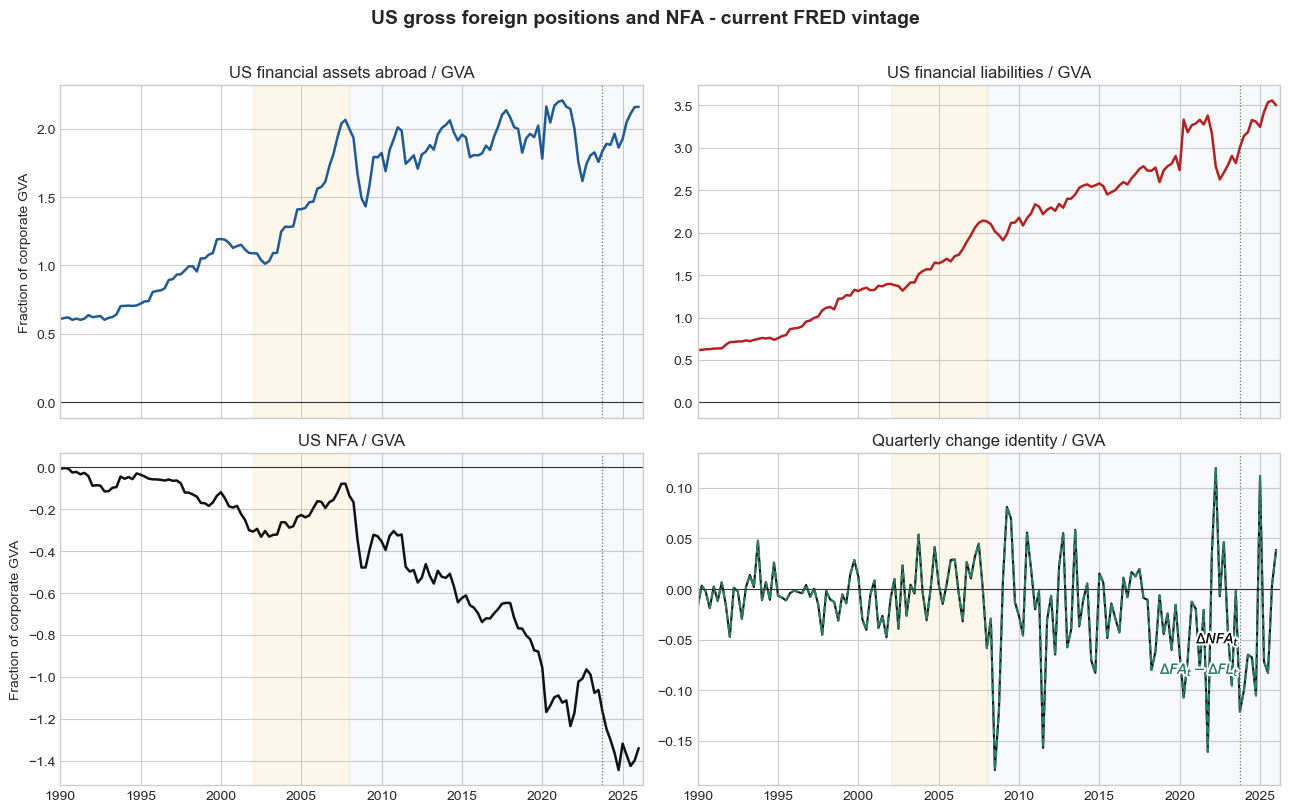

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/01_gross_positions_and_nfa_over_gva.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
plots = [
    ("fa_us_over_gva", "US financial assets abroad / GVA", COLORS["blue"]),
    ("fl_us_over_gva", "US financial liabilities / GVA", COLORS["red"]),
    ("nfa_us_over_gva", "US NFA / GVA", COLORS["black"]),
]
for ax, (col, title, color) in zip(axes.flat[:3], plots):
    ax.plot(sample.index, sample[col], color=color, linewidth=1.8)
    ax.set_title(title)
    format_time_axis(ax)

delta_nfa = sample["delta_nfa_over_gva"]
delta_gross = sample["delta_fa_over_gva"] - sample["delta_fl_over_gva"]
axes[1, 1].plot(sample.index, delta_nfa, color=COLORS["black"])
axes[1, 1].plot(sample.index, delta_gross, color=COLORS["green"], linestyle="--")
axes[1, 1].set_title("Quarterly change identity / GVA")
format_time_axis(axes[1, 1])
direct_label(axes[1, 1], delta_nfa, r"$\Delta NFA_t$", COLORS["black"], at=-8, xytext=(-6, 11))
direct_label(axes[1, 1], delta_gross, r"$\Delta FA_t-\Delta FL_t$", COLORS["green"], at=-8, xytext=(-6, -11))

for ax in axes[:, 0]:
    ax.set_ylabel("Fraction of corporate GVA")
finish_figure(fig, "01_gross_positions_and_nfa_over_gva.png", "US gross foreign positions and NFA - current FRED vintage")

## Figure 2: every underbraced equity term

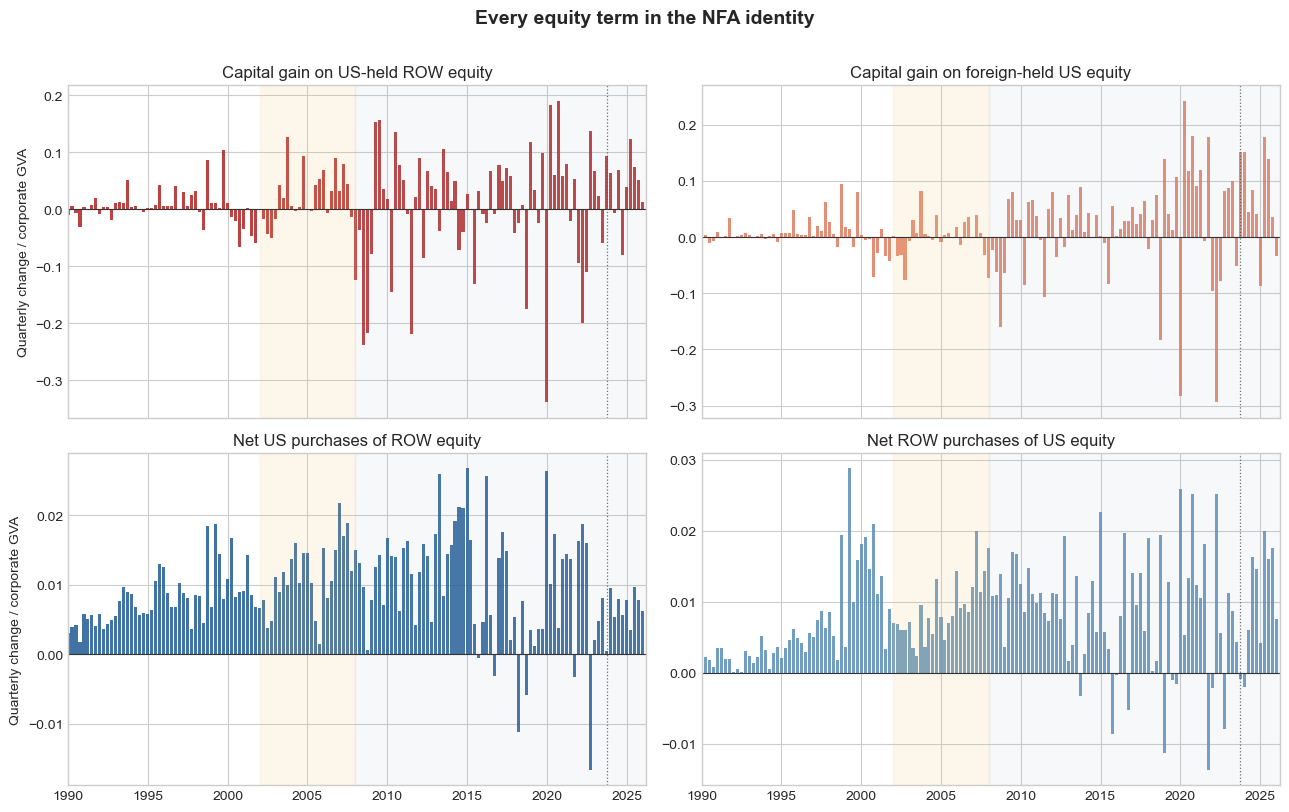

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/02_each_equity_term_over_gva.png')

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=False)
panel_specs = [
    ("gain_us_held_row_equity_over_gva", "Capital gain on US-held ROW equity", COLORS["red"]),
    ("gain_foreign_held_us_equity_over_gva", "Capital gain on foreign-held US equity", COLORS["red_light"]),
    ("purchase_us_of_row_equity_over_gva", "Net US purchases of ROW equity", COLORS["blue"]),
    ("purchase_row_of_us_equity_over_gva", "Net ROW purchases of US equity", COLORS["blue_light"]),
]
for ax, (col, title, color) in zip(axes.flat, panel_specs):
    ax.bar(sample.index, sample[col], width=70, color=color, alpha=0.85)
    ax.set_title(title)
    format_time_axis(ax)
for ax in axes[:, 0]: ax.set_ylabel("Quarterly change / corporate GVA")
finish_figure(fig, "02_each_equity_term_over_gva.png", "Every equity term in the NFA identity")

## Figure 3: net valuation, net purchases, bond change, and current account

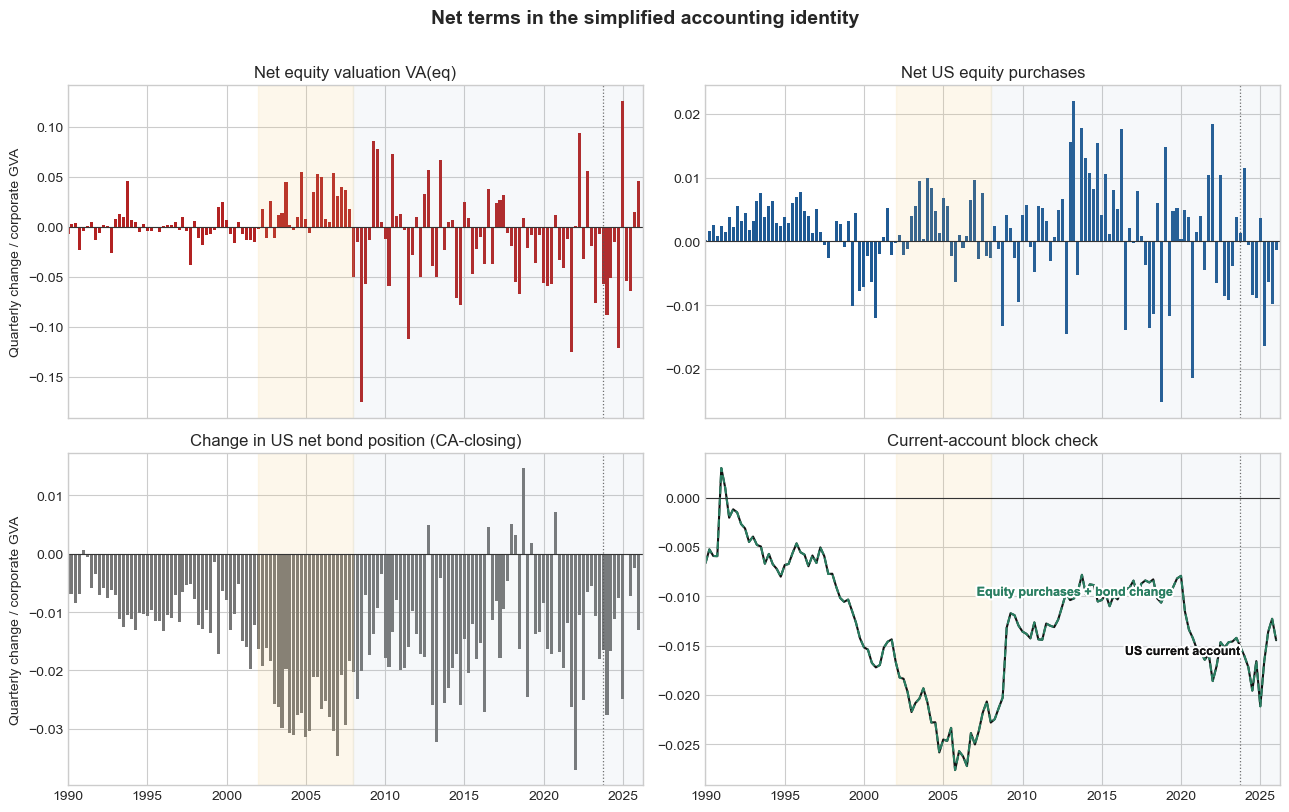

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/03_net_terms_and_current_account_over_gva.png')

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes[0, 0].bar(sample.index, sample["net_equity_valuation_over_gva"], width=70, color=COLORS["red"])
axes[0, 0].set_title("Net equity valuation VA(eq)")
axes[0, 1].bar(sample.index, sample["net_equity_purchases_over_gva"], width=70, color=COLORS["blue"])
axes[0, 1].set_title("Net US equity purchases")
axes[1, 0].bar(sample.index, sample["delta_bond_ca_closing_over_gva"], width=70, color=COLORS["gray"])
axes[1, 0].set_title("Change in US net bond position (CA-closing)")

current_account = sample["current_account_us_over_gva"]
ca_reconstruction = sample["net_equity_purchases_over_gva"] + sample["delta_bond_ca_closing_over_gva"]
axes[1, 1].plot(sample.index, current_account, color=COLORS["black"])
axes[1, 1].plot(sample.index, ca_reconstruction, color=COLORS["green"], linestyle="--")
axes[1, 1].set_title("Current-account block check")

for ax in axes.flat:
    format_time_axis(ax)
direct_label(axes[1, 1], current_account, "US current account", COLORS["black"], at=-8, xytext=(-6, 11), fontsize=9)
direct_label(
    axes[1, 1],
    ca_reconstruction,
    "Equity purchases + bond change",
    COLORS["green"],
    at=-25,
    xytext=(-6, -12),
    ha="right",
    fontsize=9,
)

for ax in axes[:, 0]:
    ax.set_ylabel("Quarterly change / corporate GVA")
finish_figure(fig, "03_net_terms_and_current_account_over_gva.png", "Net terms in the simplified accounting identity")

## Figure 4: cumulative underbraced terms

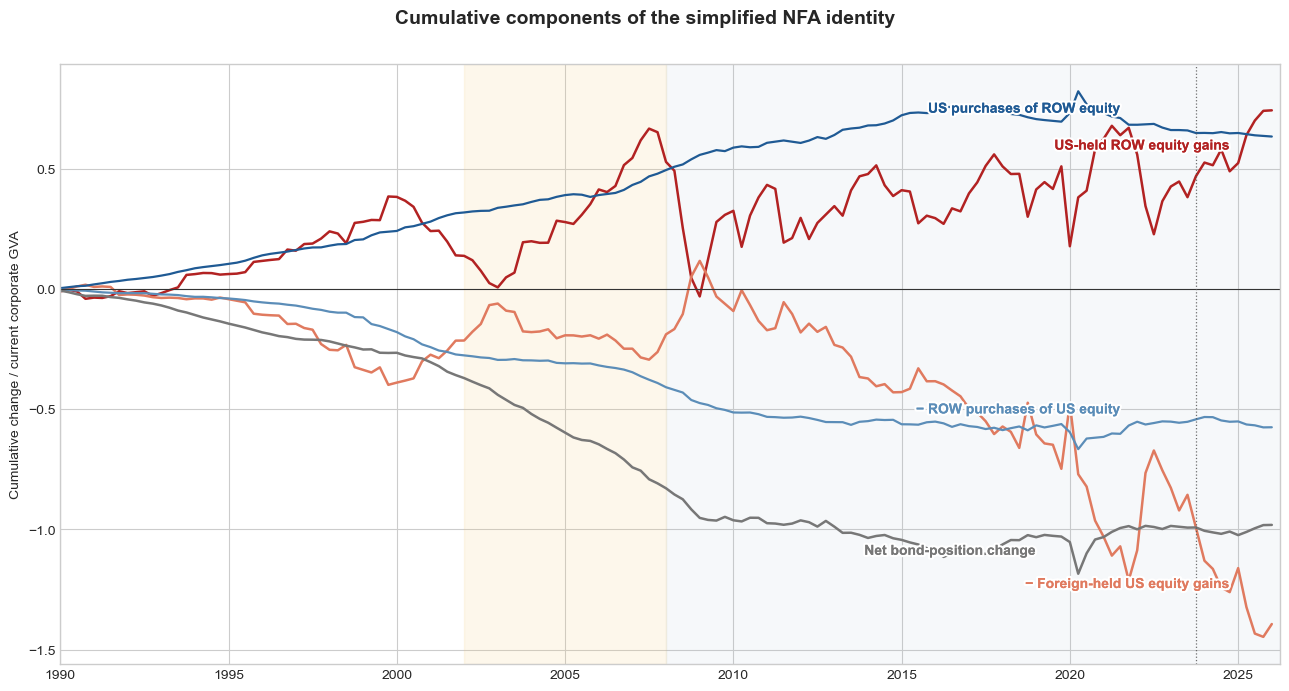

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/04_cumulative_underbraced_terms_over_gva.png')

In [9]:
fig, ax = plt.subplots(figsize=(13, 6.8))
gain_assets = sample["cum_gain_us_held_row_equity_over_gva"]
gain_liabilities = -sample["cum_gain_foreign_held_us_equity_over_gva"]
purchase_assets = sample["cum_purchase_us_of_row_equity_over_gva"]
purchase_liabilities = -sample["cum_purchase_row_of_us_equity_over_gva"]
bond_change = sample["cum_delta_bond_ca_closing_over_gva"]

ax.plot(sample.index, gain_assets, color=COLORS["red"], linewidth=1.8)
ax.plot(sample.index, gain_liabilities, color=COLORS["red_light"], linewidth=1.8)
ax.plot(sample.index, purchase_assets, color=COLORS["blue"], linewidth=1.6)
ax.plot(sample.index, purchase_liabilities, color=COLORS["blue_light"], linewidth=1.6)
ax.plot(sample.index, bond_change, color=COLORS["gray"], linewidth=1.8)
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")

direct_label(ax, gain_assets, "US-held ROW equity gains", COLORS["red"], at=-5, xytext=(-6, 12))
direct_label(ax, gain_liabilities, "− Foreign-held US equity gains", COLORS["red_light"], at=-5, xytext=(-6, -12))
direct_label(ax, purchase_assets, "US purchases of ROW equity", COLORS["blue"], at=-18, xytext=(-6, 11))
direct_label(ax, purchase_liabilities, "− ROW purchases of US equity", COLORS["blue_light"], at=-18, xytext=(-6, 11))
direct_label(ax, bond_change, "Net bond-position change", COLORS["gray"], at=-28, xytext=(-6, -12))

finish_figure(fig, "04_cumulative_underbraced_terms_over_gva.png", "Cumulative components of the simplified NFA identity")

## Figure 5: AHP Figure 2-style exact empirical reconciliation

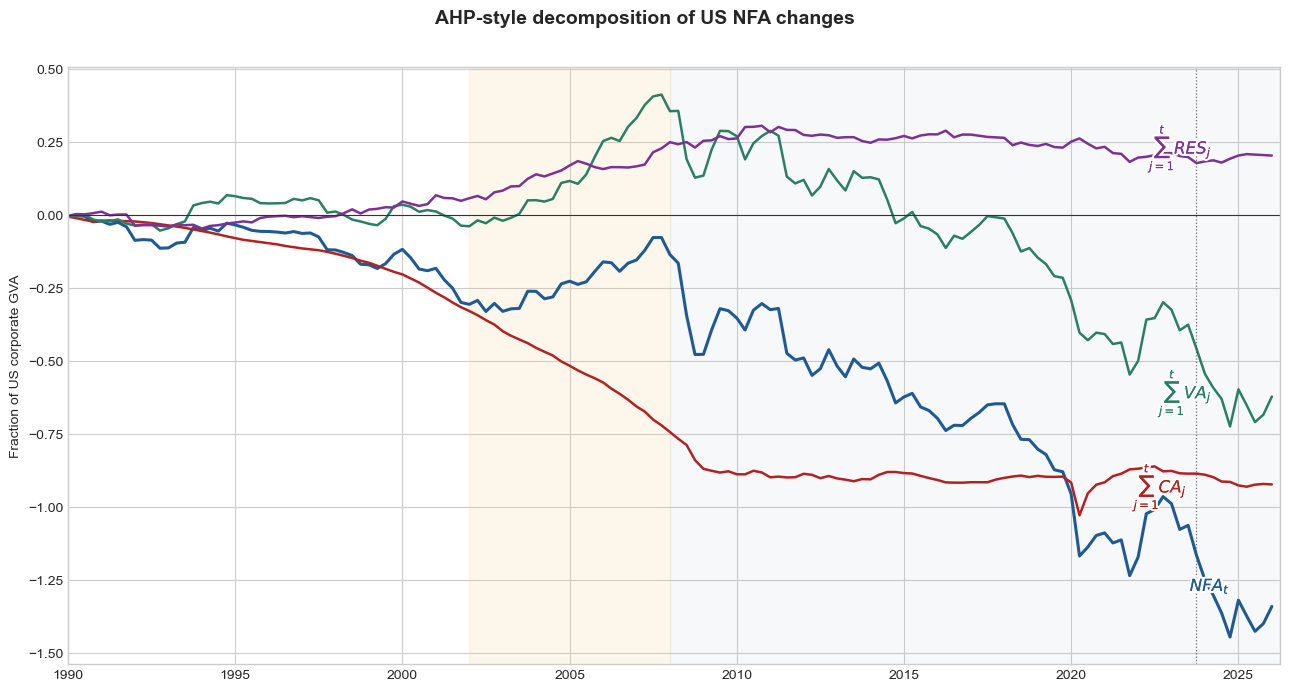

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/05_ahp_figure2_current_vintage.png')

In [10]:
fig, ax = plt.subplots(figsize=(13, 6.8))
nfa_series = sample["nfa_us_over_gva"]
cum_ca = sample["cum_current_account_us_over_gva"]
cum_va = sample["cum_total_valuation_us_over_gva"]
cum_res = sample["cum_ahp_residual_over_gva"]

ax.plot(sample.index, nfa_series, color=COLORS["blue"], linewidth=2.2)
ax.plot(sample.index, cum_ca, color=COLORS["red"], linewidth=1.8)
ax.plot(sample.index, cum_va, color=COLORS["green"], linewidth=1.8)
ax.plot(sample.index, cum_res, color=COLORS["purple"], linewidth=1.8)
format_time_axis(ax)
ax.set_ylabel("Fraction of US corporate GVA")

direct_label(ax, nfa_series, r"$NFA_t$", COLORS["blue"], at=-5, xytext=(-6, 10), fontsize=12)
direct_label(ax, cum_ca, r"$\sum_{j=1}^{t} CA_j$", COLORS["red"], at=-10, xytext=(-6, -10), fontsize=12)
direct_label(ax, cum_va, r"$\sum_{j=1}^{t} VA_j$", COLORS["green"], at=-7, xytext=(-6, 4), fontsize=12)
direct_label(ax, cum_res, r"$\sum_{j=1}^{t} RES_j$", COLORS["purple"], at=-7, xytext=(-6, 10), fontsize=12)

finish_figure(fig, "05_ahp_figure2_current_vintage.png", "AHP-style decomposition of US NFA changes")

## Figure 6: simplified identity versus the exact data reconciliation

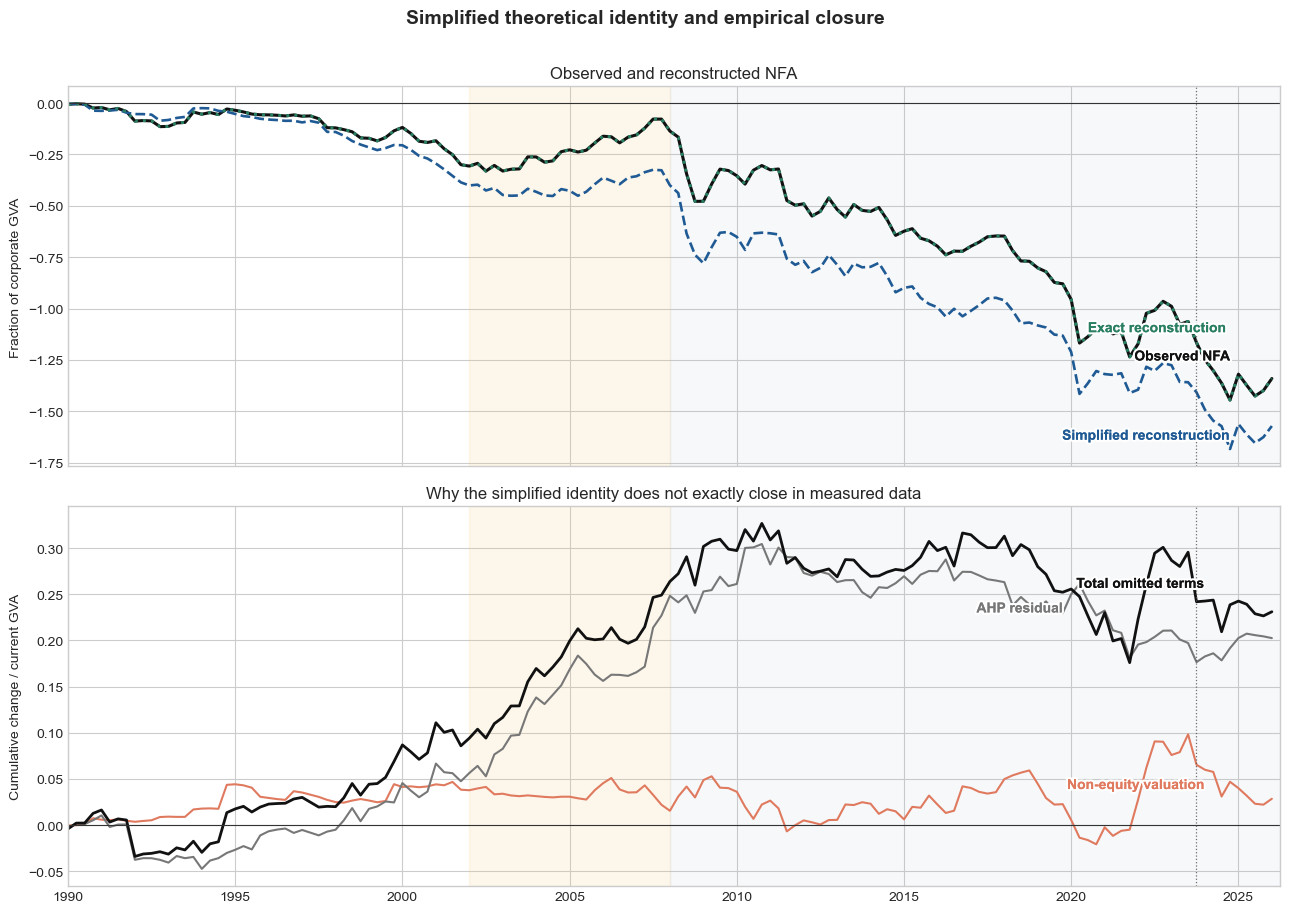

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/06_simplified_vs_exact_reconciliation.png')

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
observed_nfa = sample["nfa_us_over_gva"]
simple_nfa = sample["nfa_simple_reconstruction_over_gva"]
exact_nfa = sample["nfa_exact_reconstruction_over_gva"]

axes[0].plot(sample.index, observed_nfa, color=COLORS["black"], linewidth=2.2)
axes[0].plot(sample.index, simple_nfa, color=COLORS["blue"], linestyle="--", linewidth=1.9)
axes[0].plot(sample.index, exact_nfa, color=COLORS["green"], linestyle=":", linewidth=2.2)
axes[0].set_title("Observed and reconstructed NFA")
axes[0].set_ylabel("Fraction of corporate GVA")
format_time_axis(axes[0])
direct_label(axes[0], observed_nfa, "Observed NFA", COLORS["black"], at=-5, xytext=(-6, 12))
direct_label(axes[0], simple_nfa, "Simplified reconstruction", COLORS["blue"], at=-5, xytext=(-6, -9))
direct_label(axes[0], exact_nfa, "Exact reconstruction", COLORS["green"], at=-24, xytext=(6, 10), ha="left")

non_equity_va = sample["cum_non_equity_valuation_over_gva"]
ahp_residual = sample["cum_ahp_residual_over_gva"]
omitted_terms = sample["cum_simplified_identity_gap_over_gva"]
axes[1].plot(sample.index, non_equity_va, color=COLORS["red_light"])
axes[1].plot(sample.index, ahp_residual, color=COLORS["gray"])
axes[1].plot(sample.index, omitted_terms, color=COLORS["black"], linewidth=2)
axes[1].set_title("Why the simplified identity does not exactly close in measured data")
axes[1].set_ylabel("Cumulative change / current GVA")
format_time_axis(axes[1])
direct_label(axes[1], non_equity_va, "Non-equity valuation", COLORS["red_light"], at=-8, xytext=(-6, -10))
direct_label(axes[1], ahp_residual, "AHP residual", COLORS["gray"], at=-25, xytext=(-6, -11))
direct_label(axes[1], omitted_terms, "Total omitted terms", COLORS["black"], at=-8, xytext=(-6, 11))

finish_figure(fig, "06_simplified_vs_exact_reconciliation.png", "Simplified theoretical identity and empirical closure")

## Figure 7: cumulative equity valuation components

The two signed gross capital-gain terms sum to cumulative net equity valuation, $\sum_s VA_s$, with every series divided by contemporaneous U.S. corporate GVA.

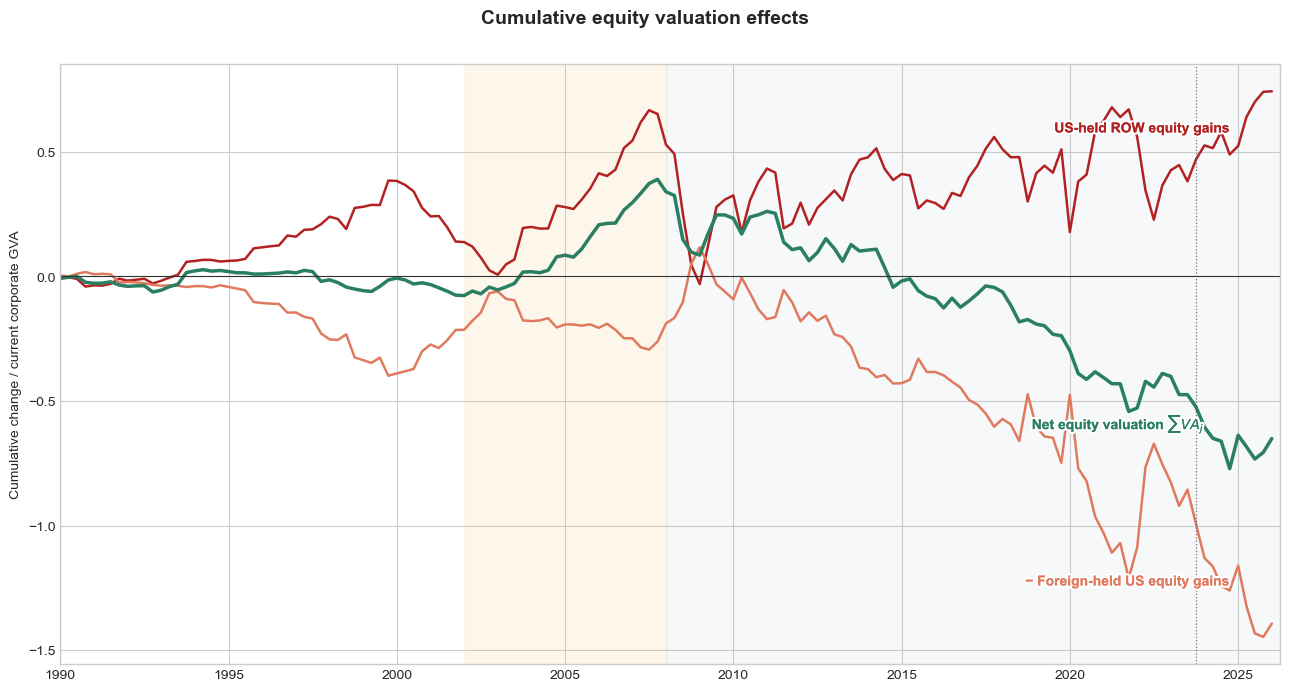

Maximum absolute cumulative VA component error: 1.110e-16


In [12]:
fig, ax = plt.subplots(figsize=(13, 6.8))
gain_assets = sample["cum_gain_us_held_row_equity_over_gva"]
gain_liabilities = -sample["cum_gain_foreign_held_us_equity_over_gva"]
net_va = sample["cum_net_equity_valuation_over_gva"]

ax.plot(sample.index, gain_assets, color=COLORS["red"], linewidth=1.8)
ax.plot(sample.index, gain_liabilities, color=COLORS["red_light"], linewidth=1.8)
ax.plot(sample.index, net_va, color=COLORS["green"], linewidth=2.5)
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")
direct_label(ax, gain_assets, "US-held ROW equity gains", COLORS["red"], at=-5, xytext=(-6, 12))
direct_label(ax, gain_liabilities, "− Foreign-held US equity gains", COLORS["red_light"], at=-5, xytext=(-6, -12))
direct_label(ax, net_va, r"Net equity valuation $\sum VA_j$", COLORS["green"], at=-8, xytext=(-6, 10))

finish_figure(
    fig,
    "07_cumulative_valuation_components_over_gva.png",
    "Cumulative equity valuation effects",
)

va_component_error = gain_assets + gain_liabilities - net_va
print(
    "Maximum absolute cumulative VA component error:",
    f"{va_component_error.abs().max():.3e}",
)

## Figure 8: cumulative current-account components

The two signed equity-purchase terms and the change in the U.S. net bond position sum to cumulative $CA$, again divided by contemporaneous U.S. corporate GVA.

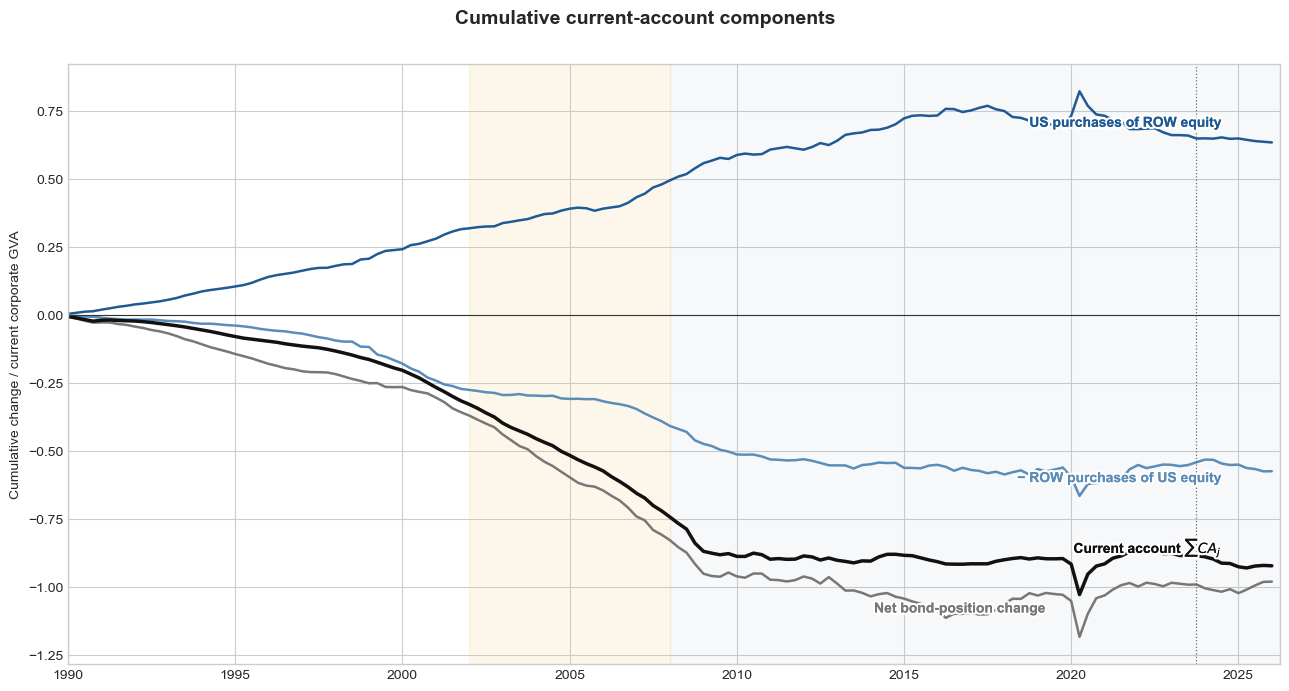

Maximum absolute cumulative CA component error: 2.220e-16


In [13]:
fig, ax = plt.subplots(figsize=(13, 6.8))
purchase_assets = sample["cum_purchase_us_of_row_equity_over_gva"]
purchase_liabilities = -sample["cum_purchase_row_of_us_equity_over_gva"]
bond_change = sample["cum_delta_bond_ca_closing_over_gva"]
cum_ca = sample["cum_current_account_us_over_gva"]

ax.plot(sample.index, purchase_assets, color=COLORS["blue"], linewidth=1.8)
ax.plot(sample.index, purchase_liabilities, color=COLORS["blue_light"], linewidth=1.8)
ax.plot(sample.index, bond_change, color=COLORS["gray"], linewidth=1.8)
ax.plot(sample.index, cum_ca, color=COLORS["black"], linewidth=2.5)
format_time_axis(ax)
ax.set_ylabel("Cumulative change / current corporate GVA")
direct_label(ax, purchase_assets, "US purchases of ROW equity", COLORS["blue"], at=-6, xytext=(-6, 11))
direct_label(ax, purchase_liabilities, "− ROW purchases of US equity", COLORS["blue_light"], at=-6, xytext=(-6, -10))
direct_label(ax, bond_change, "Net bond-position change", COLORS["gray"], at=-27, xytext=(-6, -11))
direct_label(ax, cum_ca, r"Current account $\sum CA_j$", COLORS["black"], at=-6, xytext=(-6, 11))

finish_figure(
    fig,
    "08_cumulative_current_account_components_over_gva.png",
    "Cumulative current-account components",
)

ca_component_error = purchase_assets + purchase_liabilities + bond_change - cum_ca
print(
    "Maximum absolute cumulative CA component error:",
    f"{ca_component_error.abs().max():.3e}",
)

## Figure 9: AHP Figure 3 — gross equity and non-equity positions

Current-vintage counterpart of AHP Figure 3. Equity is the IMA equity-and-investment-fund-shares level (portfolio plus FDI equity); non-equity is total gross assets or liabilities less equity.


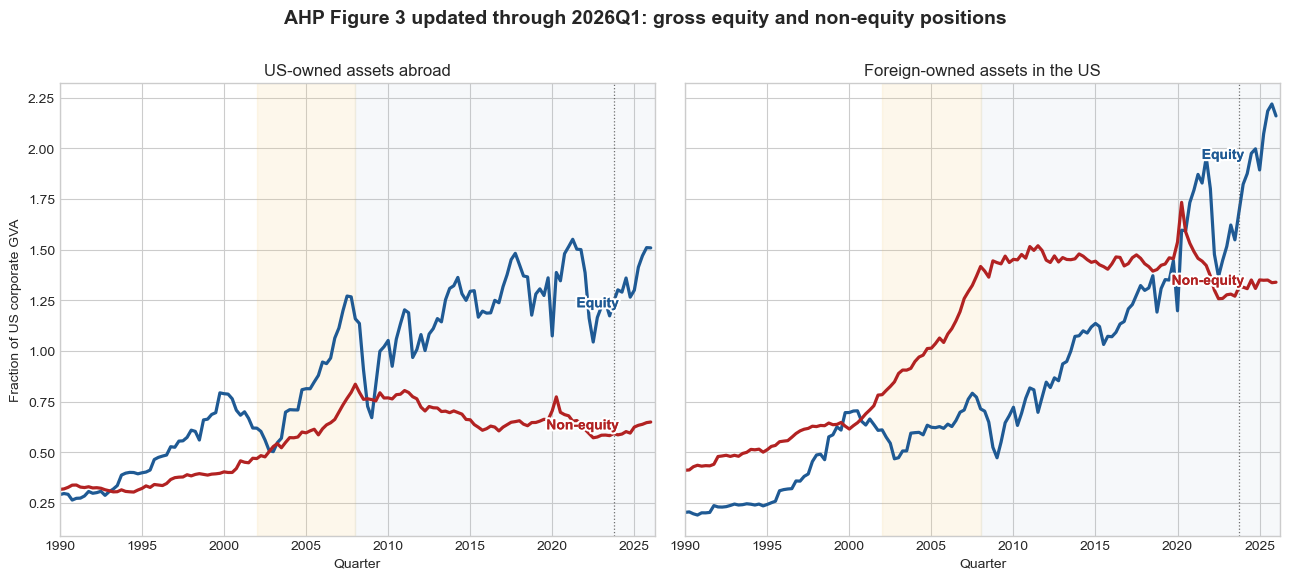

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/09_ahp_figure3_gross_equity_non_equity_positions.png')

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), sharex=True, sharey=True)

fig3_specs = [
    (
        axes[0],
        "US-owned assets abroad",
        sample["equity_assets_us_over_gva"],
        sample["non_equity_assets_us_over_gva"],
    ),
    (
        axes[1],
        "Foreign-owned assets in the US",
        sample["equity_liabilities_us_over_gva"],
        sample["non_equity_liabilities_us_over_gva"],
    ),
]

for ax, panel_title, equity, non_equity in fig3_specs:
    ax.plot(equity.index, equity, color=COLORS["blue"], linewidth=2.3)
    ax.plot(non_equity.index, non_equity, color=COLORS["red"], linewidth=2.3)
    direct_label(ax, equity, "Equity", COLORS["blue"], at=-6, xytext=(-8, -5))
    direct_label(ax, non_equity, "Non-equity", COLORS["red"], at=-6, xytext=(-8, 5))
    ax.set_title(panel_title)
    ax.set_xlabel("Quarter")
    format_time_axis(ax, zero=False)

axes[0].set_ylabel("Fraction of US corporate GVA")
figure_9_path = finish_figure(
    fig,
    "09_ahp_figure3_gross_equity_non_equity_positions.png",
    f"AHP Figure 3 updated through {LATEST_QUARTER}: gross equity and non-equity positions",
)
figure_9_path


## Figure 10: AHP Figure 4 — valuation effects and equity prices

The left panel cumulates net equity and non-equity revaluations from 1990Q1 and divides each cumulative dollar total by current-quarter corporate GVA. The right panel chains the IMA revaluation return for each gross equity position and rebases both dollar price indexes to 2009Q1 = 1.


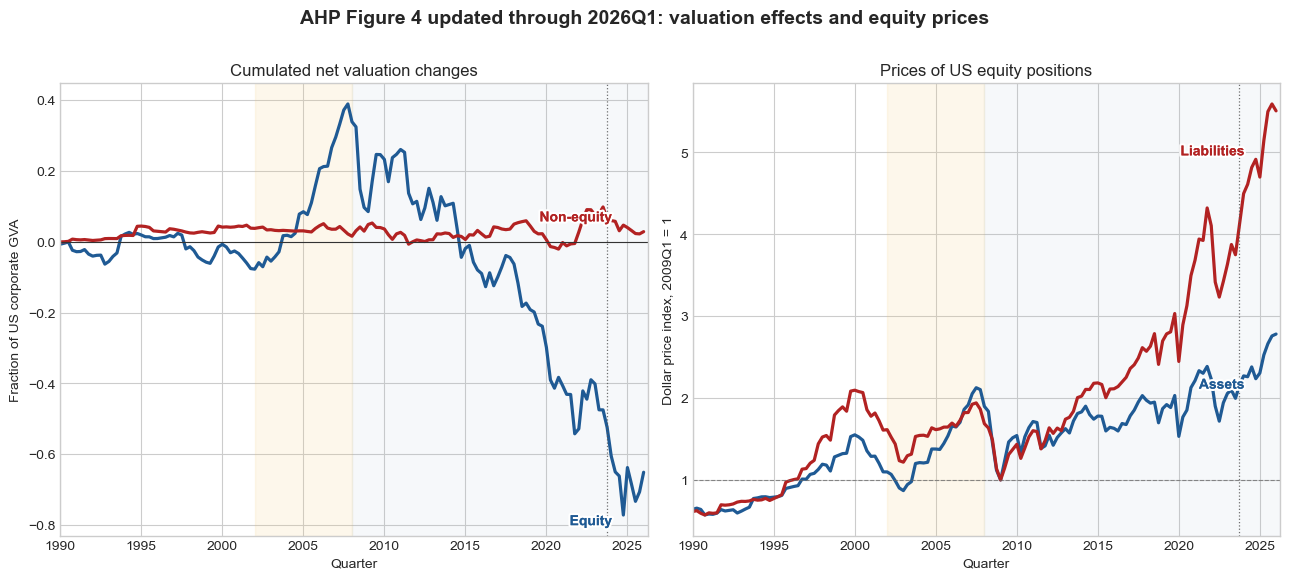

PosixPath('/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_production/Data/figures_ahp_nfa/10_ahp_figure4_valuation_effects_and_equity_prices.png')

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.7), sharex=True)

equity_cumulative = sample["cum_net_equity_valuation_over_gva"]
non_equity_cumulative = sample["cum_non_equity_valuation_over_gva"]
axes[0].plot(
    equity_cumulative.index,
    equity_cumulative,
    color=COLORS["blue"],
    linewidth=2.3,
)
axes[0].plot(
    non_equity_cumulative.index,
    non_equity_cumulative,
    color=COLORS["red"],
    linewidth=2.3,
)
direct_label(
    axes[0], equity_cumulative, "Equity", COLORS["blue"], at=-6, xytext=(-8, -5)
)
direct_label(
    axes[0], non_equity_cumulative, "Non-equity", COLORS["red"], at=-6, xytext=(-8, 5)
)
axes[0].set_title("Cumulated net valuation changes")
axes[0].set_ylabel("Fraction of US corporate GVA")
axes[0].set_xlabel("Quarter")
format_time_axis(axes[0])

asset_prices = sample["equity_asset_price_index"]
liability_prices = sample["equity_liability_price_index"]
axes[1].plot(
    asset_prices.index,
    asset_prices,
    color=COLORS["blue"],
    linewidth=2.3,
)
axes[1].plot(
    liability_prices.index,
    liability_prices,
    color=COLORS["red"],
    linewidth=2.3,
)
axes[1].axhline(1.0, color="#666666", linewidth=0.8, linestyle="--", alpha=0.7)
direct_label(
    axes[1], asset_prices, "Assets", COLORS["blue"], at=-6, xytext=(-8, -5)
)
direct_label(
    axes[1], liability_prices, "Liabilities", COLORS["red"], at=-6, xytext=(-8, 5)
)
axes[1].set_title("Prices of US equity positions")
axes[1].set_ylabel("Dollar price index, 2009Q1 = 1")
axes[1].set_xlabel("Quarter")
format_time_axis(axes[1], zero=False)

figure_10_path = finish_figure(
    fig,
    "10_ahp_figure4_valuation_effects_and_equity_prices.png",
    f"AHP Figure 4 updated through {LATEST_QUARTER}: valuation effects and equity prices",
)
figure_10_path


## Interpretation

The plots preserve the three phases emphasized in the AHP comparison and add an explicitly out-of-paper extension:

1. **1990-2001:** NFA mostly follows cumulative current-account deficits.
2. **2002-2007:** valuation privilege - gains on US-held foreign equity exceed gains accruing to foreigners on US equity.
3. **2008-2023Q3:** the sign reverses. Capital gains on foreign-held US equity dominate, producing a large negative net equity valuation term even though net US equity purchases are generally positive for NFA.
4. **2023Q4-latest common quarter:** the same accounting and normalization are extended mechanically using the current data vintage. The dotted vertical line identifies the previous 2023Q3 endpoint.

Because these are current-vintage FRED data, both historical and extended paths may differ from AHP's published replication vintage. Moreover, `total_valuation_us_musd` is observed total valuation; it is not a bubble-specific valuation component.

Figures 9 and 10 reproduce AHP's gross equity/non-equity decomposition and its valuation/price-index comparison with the same IMA concepts. The equity price indexes are accounting-implied dollar indexes, not external stock-market indexes: each quarterly price growth rate is the corresponding IMA equity revaluation divided by the lagged gross equity position.
